Importation des bibliothéques

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

PREPARATION DES DONNEES

Importation des données

In [ ]:
chemin = "/content/0Bankruptcy_T.csv" #a adapter
df = pd.read_csv(chemin)
#print(df.info(), df.duplicated().sum())

Nettoyage des données

In [ ]:
#Les données sont propres (pas de doublons, pas de null)

Normalisation

In [ ]:
y = df['Bankrupt?']
X = df.drop(columns=['Bankrupt?'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

COMPARAISON DES PERFORMANCES DES ALGORITHMES
(la precision, rappel (recall), f1-score pondere, le taux de classification correct (accuracy), le temps necessaire pour obtenir les resultats, et les principaux
hyperparametres utilises)

Régression Logistique

In [ ]:
start_time = time.perf_counter()

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Temps d'execution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

Temps d'execution : 0.0893 secondes
Accuracy : 0.8859
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       927
           1       0.16      0.68      0.26        28

    accuracy                           0.89       955
   macro avg       0.57      0.79      0.60       955
weighted avg       0.96      0.89      0.92       955



K plus proches voisins

In [ ]:
start_time = time.perf_counter()

model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Temps d'execution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

Temps d'execution : 0.0738 secondes
Accuracy : 0.9696
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       927
           1       0.45      0.18      0.26        28

    accuracy                           0.97       955
   macro avg       0.72      0.59      0.62       955
weighted avg       0.96      0.97      0.96       955



Random Forest

In [ ]:
start_time = time.perf_counter()

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Temps d'execution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

Temps d'execution : 1.6340 secondes
Accuracy : 0.9717
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       927
           1       0.67      0.07      0.13        28

    accuracy                           0.97       955
   macro avg       0.82      0.54      0.56       955
weighted avg       0.96      0.97      0.96       955



Machine a vecteur de support

In [ ]:
start_time = time.perf_counter()

model = SVC(class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Temps d'execution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

Temps d'execution : 0.4176 secondes
Accuracy : 0.9152
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.99      0.93      0.95       927
           1       0.18      0.54      0.27        28

    accuracy                           0.92       955
   macro avg       0.58      0.73      0.61       955
weighted avg       0.96      0.92      0.93       955



Reseaux de neurones

In [ ]:
start_time = time.perf_counter()

model = MLPClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Temps d'execution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

Temps d'execution : 9.0001 secondes
Accuracy : 0.9707
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       927
           1       0.50      0.25      0.33        28

    accuracy                           0.97       955
   macro avg       0.74      0.62      0.66       955
weighted avg       0.96      0.97      0.97       955



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


XGBoost

In [ ]:
start_time = time.perf_counter()

model = XGBClassifier(scale_pos_weight=32, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

end_time = time.perf_counter()
execution_time = end_time - start_time

print(f"Temps d'execution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:47:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Temps d'execution : 0.7294 secondes
Accuracy : 0.9696
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       927
           1       0.47      0.25      0.33        28

    accuracy                           0.97       955
   macro avg       0.72      0.62      0.66       955
weighted avg       0.96      0.97      0.97       955



CHOIX DES VARIABLES SUR RANDOM FOREST

In [ ]:
df_feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
df_feature_importance = df_feature_importance.sort_values(by='Importance', ascending=False)

df_top10 = df_feature_importance.head(10)
df_top30 = df_feature_importance.head(30)

df_seuil01 = df_feature_importance[df_feature_importance['Importance'] >= 0.01]
df_seuil001 = df_feature_importance[df_feature_importance['Importance'] >= 0.001]

idx = X.columns.get_indexer(df_top10['Feature'])
X_train_top10 = X_train_scaled[:, idx]
X_test_top10 = X_test_scaled[:, idx]

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_top10, y_train)
y_pred = model.predict(X_test_top10)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

idx = X.columns.get_indexer(df_top30['Feature'])
X_train_top30 = X_train_scaled[:, idx]
X_test_top30 = X_test_scaled[:, idx]

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_top30, y_train)
y_pred = model.predict(X_test_top30)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

idx = X.columns.get_indexer(df_seuil01['Feature'])
X_train_seuil01 = X_train_scaled[:, idx]
X_test_seuil01 = X_test_scaled[:, idx]

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_seuil01, y_train)
y_pred = model.predict(X_test_seuil01)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

idx = X.columns.get_indexer(df_seuil001['Feature'])
X_train_seuil001 = X_train_scaled[:, idx]
X_test_seuil001 = X_test_scaled[:, idx]

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_seuil001, y_train)
y_pred = model.predict(X_test_seuil001)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Rapport de classification : \n{classification_report(y_test, y_pred)}")

Accuracy : 0.9696
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       927
           1       0.33      0.04      0.06        28

    accuracy                           0.97       955
   macro avg       0.65      0.52      0.52       955
weighted avg       0.95      0.97      0.96       955

Accuracy : 0.9717
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       927
           1       0.60      0.11      0.18        28

    accuracy                           0.97       955
   macro avg       0.79      0.55      0.58       955
weighted avg       0.96      0.97      0.96       955

Accuracy : 0.9717
Rapport de classification : 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       927
           1       0.60      0.11      0.18        28

    accuracy                           0.

CHOIX DES HYPERPARAMETRES SUR RANDOM FOREST ET RESEAUX DE NEURONNES

Random Forest

In [ ]:
start_time = time.perf_counter()

param_rf = {'n_estimators' : [50, 100], 'max_depth' : [10, 20], 'max_features' : ['sqrt', 'log2']}
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search_rf = GridSearchCV(model_rf, param_rf, cv=5, scoring='f1_weighted')
grid_search_rf.fit(X_train_scaled, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

execution_time = time.perf_counter() - start_time

print(f"Meilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Temps d'exécution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Meilleurs paramètres : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Temps d'exécution : 38.1604 secondes
Accuracy : 0.9707
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       927
           1       0.50      0.43      0.46        28

    accuracy                           0.97       955
   macro avg       0.74      0.71      0.72       955
weighted avg       0.97      0.97      0.97       955



Reseaux de neuronnes

In [ ]:
start_time = time.perf_counter()

param_MLP = {'hidden_layer_sizes': [(50,), (100,), (50, 50)], 'activation': ['tanh', 'relu'], 'solver': ['adam'], 'max_iter': [300]}
model_MLP = MLPClassifier(random_state=42)

grid_search_MLP = GridSearchCV(model_MLP, param_MLP, cv=5, scoring='f1_weighted')
grid_search_MLP.fit(X_train_scaled, y_train)

best_MLP = grid_search_MLP.best_estimator_
y_pred = best_MLP.predict(X_test_scaled)

execution_time = time.perf_counter() - start_time

print(f"Meilleurs paramètres : {grid_search_MLP.best_params_}")
print(f"Temps d'exécution : {execution_time:.4f} secondes")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Meilleurs paramètres : {'activation': 'relu', 'hidden_layer_sizes': (100,), 'max_iter': 300, 'solver': 'adam'}
Temps d'exécution : 292.6030 secondes
Accuracy : 0.9696
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       927
           1       0.46      0.21      0.29        28

    accuracy                           0.97       955
   macro avg       0.72      0.60      0.64       955
weighted avg       0.96      0.97      0.96       955



CHOIX DU MODELE LE PLUS PERFORMANT

Courbe ROC pour Random Forest

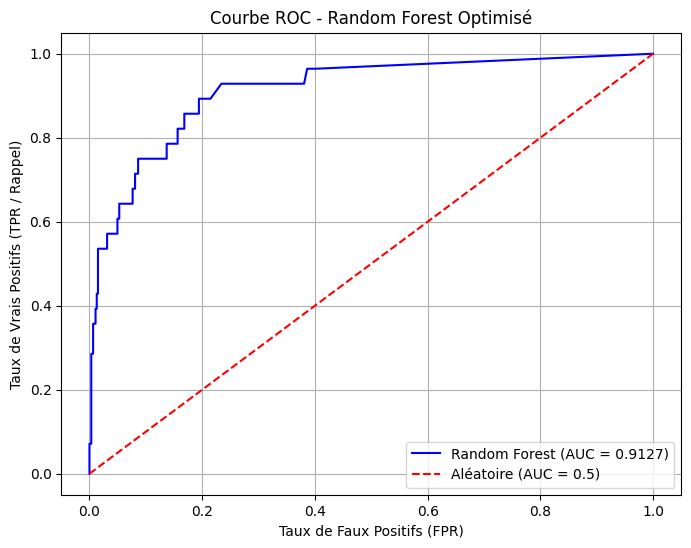

In [ ]:
y_probs = best_rf.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR / Rappel)')
plt.title('Courbe ROC - Random Forest Optimisé')
plt.legend()
plt.grid(True)
plt.show()

MERCI PAUL que j'aime d'amour !!! on te doit des bieres <3
Pas de soucis mdr ! ou sinon un stage aussi je veux bien